In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

plt.style.use("seaborn-v0_8")

with open("../data/preprocessed/subgraph.pkl", "rb") as f:
    H = pickle.load(f)

print("Loaded H:", H.number_of_nodes(), "nodes,", H.number_of_edges(), "edges")

# Load centralities
cent_df = pd.read_csv("../data/preprocessed/node_centralities.csv")
cent_df.head()


Loaded H: 1000 nodes, 28675 edges


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
0,720575940603464672,AL.LH.7,0.103103,0.293342,0.012181,0.000071,0.000821
1,720575940605758142,AL.14,0.178178,0.301209,0.001826,0.000239,0.001955
2,720575940606722249,AL.45,0.182182,0.311880,0.000995,0.000171,0.001816
3,720575940609282825,AL.3,0.174174,0.316323,0.022744,0.000224,0.001811
4,720575940610161091,AL.80,0.175175,0.305828,0.000033,0.000135,0.001672


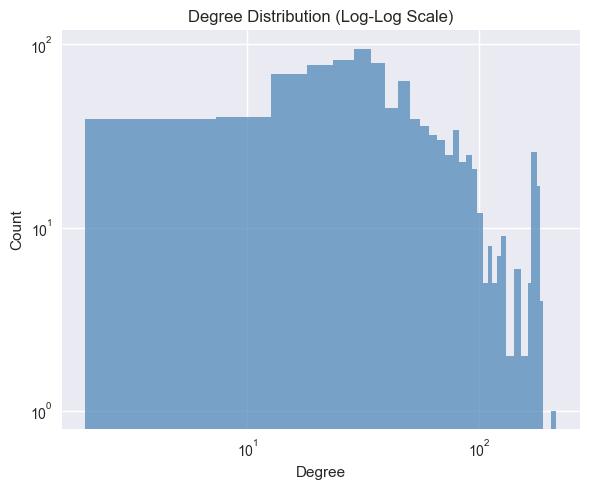

In [6]:
# Degree distribution
deg = [d for _, d in H.degree()]

plt.figure(figsize=(6,5))
plt.hist(deg, bins=40, color="steelblue", alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution (Log-Log Scale)")
plt.tight_layout()
plt.show()


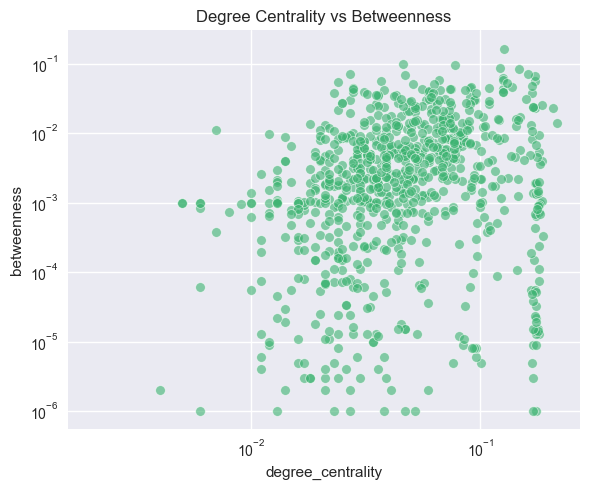

In [7]:
#Degree vs Centrality
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=cent_df,
    x="degree_centrality",
    y="betweenness",
    alpha=0.6,
    color="mediumseagreen"
)
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Centrality vs Betweenness")
plt.tight_layout()
plt.show()


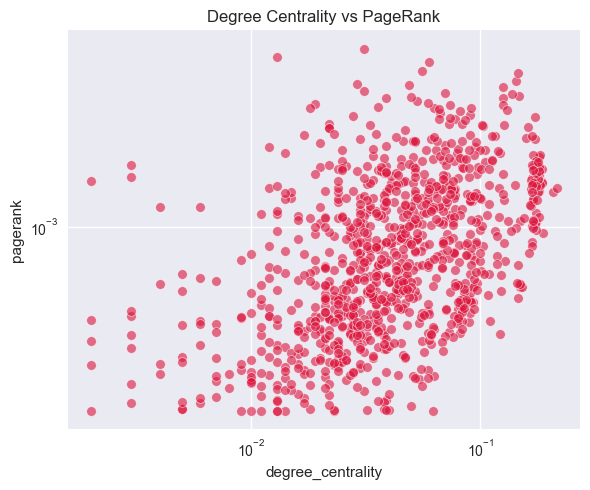

In [9]:
#Page rank vs Degree
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=cent_df,
    x="degree_centrality",
    y="pagerank",
    alpha=0.6,
    color="crimson"
)
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Centrality vs PageRank")
plt.tight_layout()
plt.show()



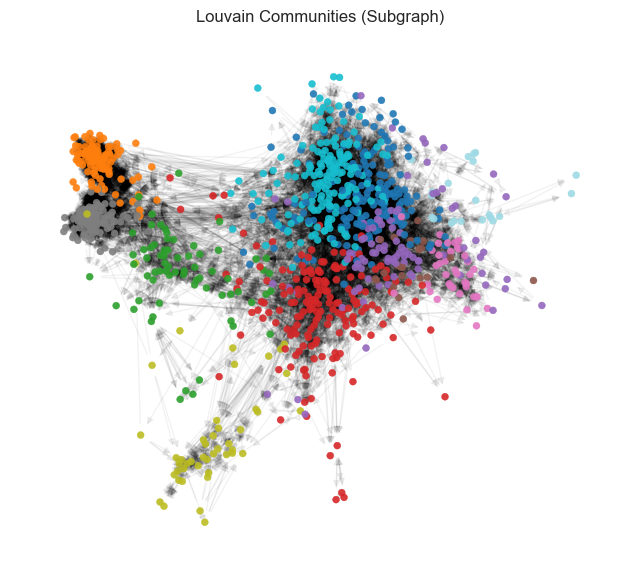

In [10]:
# Get community ID for each node
comms = [H.nodes[n].get("louvain", 0) for n in H.nodes()]
pos = nx.spring_layout(H, seed=42, k=0.15)

plt.figure(figsize=(8,7))
nx.draw_networkx_nodes(
    H, pos,
    node_color=comms,
    cmap="tab20",
    node_size=25,
    alpha=0.9
)
nx.draw_networkx_edges(H, pos, alpha=0.05)
plt.title("Louvain Communities (Subgraph)")
plt.axis("off")
plt.show()


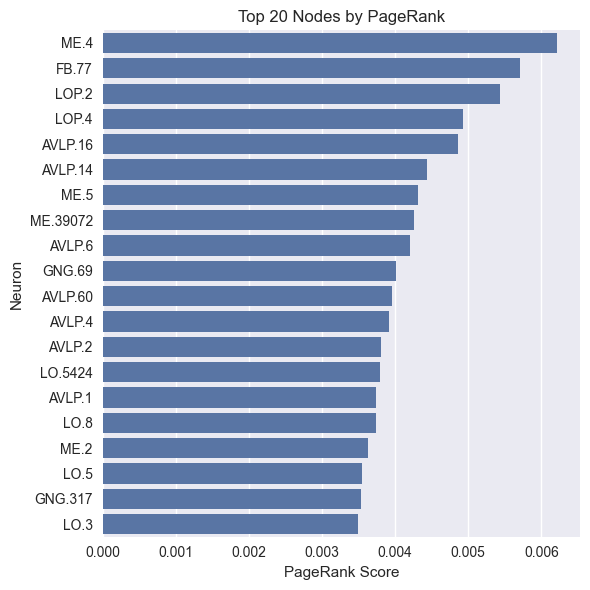

In [14]:
#Top Pagerank nodes
top_pagerank = cent_df.sort_values("pagerank", ascending=False).head(20)

plt.figure(figsize=(6,6))
sns.barplot(
    data=top_pagerank,
    y="name",
    x="pagerank",
   
)
plt.title("Top 20 Nodes by PageRank")
plt.xlabel("PageRank Score")
plt.ylabel("Neuron")
plt.tight_layout()
plt.show()


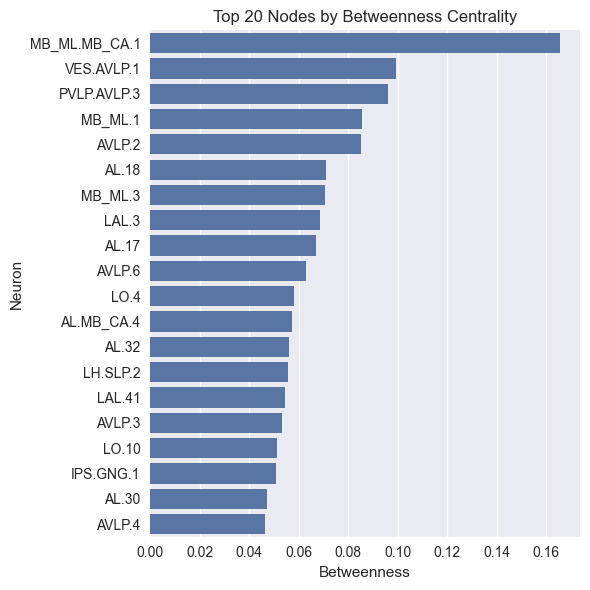

In [15]:
# TopBetweennes nodes
top_between = cent_df.sort_values("betweenness", ascending=False).head(20)

plt.figure(figsize=(6,6))
sns.barplot(
    data=top_between,
    y="name",
    x="betweenness",
    
)
plt.title("Top 20 Nodes by Betweenness Centrality")
plt.xlabel("Betweenness")
plt.ylabel("Neuron")
plt.tight_layout()
plt.show()
